# **Rice Quality Classification Comparison**

## **Data Exploration and Visualization**

### **Import Libraries**

In [45]:
import os
import gc
import logging
import random
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as preprocess_mobilenet,
)
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as preprocess_resnet,
)
from tensorflow.keras.applications.efficientnet import (
    preprocess_input as preprocess_efficientnet,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

### **Mount Google Drive**

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### **Dataset Path Definition**

In [3]:
# Main directory path
BASE_DIR = "/content/drive/MyDrive/Dataset/rice"

# Define 4 label names
LABELS = ["whole", "chalky", "broken", "discolored"]

# Dictionary to store the path for each label
label_paths = {lbl: os.path.join(BASE_DIR, lbl) for lbl in LABELS}

# Verify the number of image files in each label folder
for lbl, path in label_paths.items():
    if os.path.exists(path):
        image_count = len(
            [
                f
                for f in os.listdir(path)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ]
        )
        print(f"Label '{lbl}': Found {image_count} images.")
    else:
        print(f"Warning: Path for label '{lbl}' not found at {path}")

Label 'whole': Found 250 images.
Label 'chalky': Found 250 images.
Label 'broken': Found 250 images.
Label 'discolored': Found 250 images.


### **Dataset Distribution Visualization**

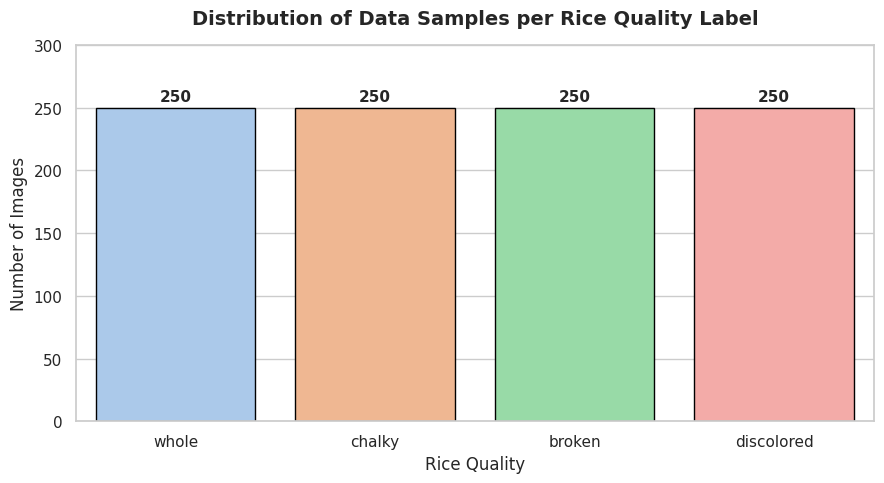

In [4]:
# Preparing quantitative data
label_counts = []
for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        count = len(
            [
                f
                for f in os.listdir(path)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ]
        )
        label_counts.append(count)
    else:
        label_counts.append(0)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=LABELS,
    y=label_counts,
    hue=LABELS,
    palette="pastel",
    legend=False,
    edgecolor="black",
)

# Value labels above each bar plot
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.title(
    "Distribution of Data Samples per Rice Quality Label",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Rice Quality", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.ylim(0, max(label_counts) + 50)
plt.tight_layout()
plt.show()

### **Rice Image Sample Visualization**

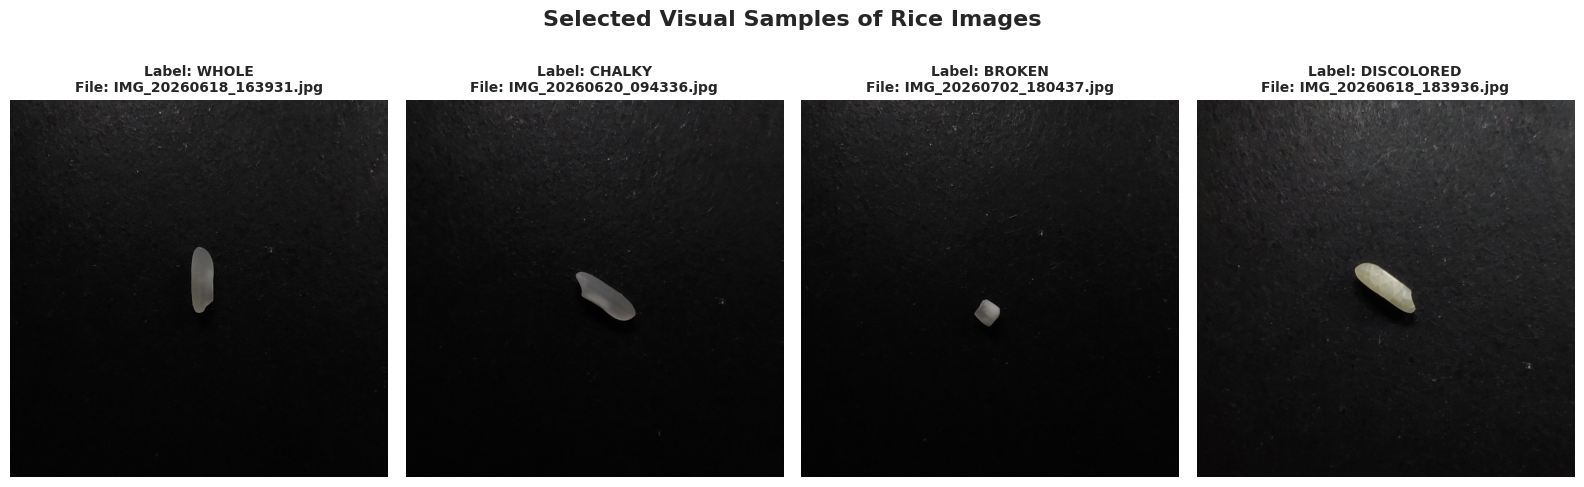

In [5]:
# Random image samples
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    path = label_paths[lbl]
    if os.path.exists(path):
        # Get list of all image files inside the label folder
        image_files = [
            f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        if image_files:
            # Select a random file
            random_file = random.choice(image_files)
            img_path = os.path.join(path, random_file)

            # Read image and convert color space from BGR to RGB
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Subplot
            axes[i].imshow(img_rgb)
            axes[i].set_title(
                f"Label: {lbl.upper()}\nFile: {random_file}",
                fontsize=10,
                fontweight="bold",
            )
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, "Empty Folder", ha="center", va="center")
            axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, "Path Not Found", ha="center", va="center")
        axes[i].axis("off")

plt.suptitle(
    "Selected Visual Samples of Rice Images", fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

## **Image Enhancement**

### **Filter**

In [6]:
def enhance_image(image):
    # Light Gaussian Blur to reduce camera sensor noise
    enhanced_img = cv2.GaussianBlur(image, (3, 3), 0)
    return enhanced_img

## **Preprocessing**

### **Background Segmentation and Resizing**

In [7]:
def preprocess_grain_image(image, target_size=(224, 224)):
    # Convert color space to HSV for segmentation accuracy
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    v_channel = hsv_image[:, :, 2]
    max_v = np.max(v_channel) if np.max(v_channel) > 0 else 1
    h_img, w_img = v_channel.shape[:2]

    # Filter objects based on pure rice grain geometry
    def find_valid_grain_contour(thresh_value):
        _, binary_mask = cv2.threshold(v_channel, thresh_value, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(
            binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        if not contours:
            return None, binary_mask

        # Sort from largest to smallest area
        sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for c in sorted_contours:
            area = cv2.contourArea(c)
            if area < 100:
                continue

            x, y, w, h = cv2.boundingRect(c)

            # Filter if the object covers > 70% of the image dimensions
            if w >= (w_img * 0.70) or h >= (h_img * 0.70):
                continue

            # Solidity / convexity density check filter
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            solidity = float(area) / hull_area if hull_area > 0 else 0
            if solidity < 0.72:
                continue

            return c, binary_mask

        return None, binary_mask

    # Find rice grain using standard threshold
    thresh_1 = max(int(max_v * 0.35), 50)
    selected_contour, final_mask = find_valid_grain_contour(thresh_1)

    # If failed, use high threshold
    if selected_contour is None:
        thresh_2 = max(int(max_v * 0.55), 80)
        selected_contour, final_mask = find_valid_grain_contour(thresh_2)

    # Create pure binary mask
    clean_mask = np.zeros_like(final_mask)
    if selected_contour is not None:
        cv2.drawContours(clean_mask, [selected_contour], -1, 255, thickness=cv2.FILLED)
        x, y, w, h = cv2.boundingRect(selected_contour)
    else:
        # Pick the object closest to the image center
        contours, _ = cv2.findContours(
            final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        valid_fallback = None
        min_dist = float("inf")

        for cnt in contours:
            mx, my, mw, mh = cv2.boundingRect(cnt)
            if mw < (w_img * 0.60) and mh < (h_img * 0.60):
                dist = abs((mx + mw / 2) - w_img / 2) + abs((my + mh / 2) - h_img / 2)
                if dist < min_dist:
                    min_dist = dist
                    valid_fallback = cnt

        if valid_fallback is not None:
            cv2.drawContours(
                clean_mask, [valid_fallback], -1, 255, thickness=cv2.FILLED
            )
            x, y, w, h = cv2.boundingRect(valid_fallback)
        else:
            x, y, w, h = 0, 0, w_img, h_img

    # Extract absolute black binary image
    segmented_image = cv2.bitwise_and(
        image,
        image,
        mask=(
            clean_mask
            if selected_contour is not None or "valid_fallback" in locals()
            else final_mask
        ),
    )

    # Crop and apply 1:1 Square Padding
    grain_crop = segmented_image[y : y + h, x : x + w]
    max_side = max(w, h) if max(w, h) > 0 else 1
    grain_square = np.zeros((max_side, max_side, 3), dtype=np.uint8)
    df_x = (max_side - w) // 2
    df_y = (max_side - h) // 2
    grain_square[df_y : df_y + h, df_x : df_x + w] = grain_crop

    resized_image = cv2.resize(grain_square, target_size, interpolation=cv2.INTER_AREA)
    final_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

    return final_image

### **Dataset Extraction and Data Splitting Pipeline**

In [8]:
# Initialize lists to store image matrices and numerical labels
features_data = []
labels_data = []

# Map string label names to integer indices
label_map = {lbl: idx for idx, lbl in enumerate(LABELS)}

print("Starting dataset processing...")

for lbl in LABELS:
    path = label_paths[lbl]
    if os.path.exists(path):
        image_files = [
            f for f in os.listdir(path) if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        current_count = 0

        for file_name in image_files:
            img_full_path = os.path.join(path, file_name)
            raw_img = cv2.imread(img_full_path)

            if raw_img is not None:
                # Sequential image enhancement filter
                enhanced_img = enhance_image(raw_img)

                # Absolute black background segmentation & resizing
                processed_img = preprocess_grain_image(
                    enhanced_img, target_size=(224, 224)
                )

                # Normalize pixel values to 0-1 scale for model convergence stability
                normalized_img = processed_img / 255.0

                features_data.append(normalized_img)
                labels_data.append(label_map[lbl])
                current_count += 1

        print(f" -> Successfully processed {current_count} images for label: {lbl}")

# Convert array data structures
X = np.array(features_data, dtype=np.float32)
y = np.array(labels_data, dtype=np.int32)

print("\nFinal shape of dataset matrices:")
print(" - Feature Matrix X:", X.shape)
print(" - Label Matrix y:", y.shape)

# Stratified data splitting
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nData Splitting Results:")
print(f" -> Total Training Data   : {X_train.shape[0]} samples")
print(f" -> Total Validation Data : {X_val.shape[0]} samples\n")

# Verify sample counts per label
for i, lbl in enumerate(LABELS):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    print(f"Label '{lbl}': Train = {train_count} images, Val = {val_count} images.")

# Convert split arrays back to TensorFlow format
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (
    train_dataset.shuffle(buffer_size=len(X_train)).batch(32).prefetch(tf.data.AUTOTUNE)
)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

Starting dataset processing...
 -> Successfully processed 250 images for label: whole
 -> Successfully processed 250 images for label: chalky
 -> Successfully processed 250 images for label: broken
 -> Successfully processed 250 images for label: discolored

Final shape of dataset matrices:
 - Feature Matrix X: (1000, 224, 224, 3)
 - Label Matrix y: (1000,)

Data Splitting Results:
 -> Total Training Data   : 800 samples
 -> Total Validation Data : 200 samples

Label 'whole': Train = 200 images, Val = 50 images.
Label 'chalky': Train = 200 images, Val = 50 images.
Label 'broken': Train = 200 images, Val = 50 images.
Label 'discolored': Train = 200 images, Val = 50 images.


### **Preprocessing Results Visualization**

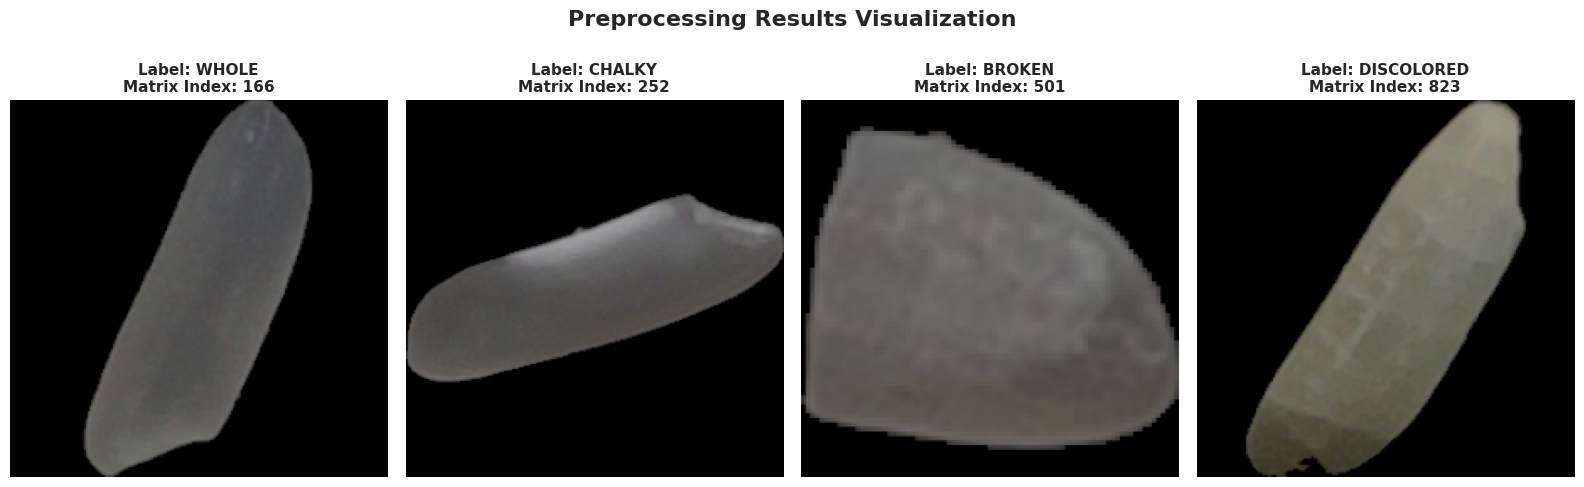

In [9]:
# Comparison of preprocessing results
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, lbl in enumerate(LABELS):
    # Find all matrix indices corresponding to the label
    indices = np.where(y == i)[0]

    if len(indices) > 0:
        # Randomly select one index for the label
        random_idx = random.choice(indices)

        # Processed image result
        axes[i].imshow(X[random_idx])
        axes[i].set_title(
            f"Label: {lbl.upper()}\nMatrix Index: {random_idx}",
            fontsize=11,
            fontweight="bold",
        )
        axes[i].axis("off")
    else:
        axes[i].text(0.5, 0.5, "Empty Data", ha="center", va="center")
        axes[i].axis("off")

plt.suptitle(
    "Preprocessing Results Visualization", fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### **Export Preprocessed Rice Samples**

In [10]:
# Destination folder name
SAVE_DIR = "/content/drive/MyDrive/Dataset/rice_preprocessing_comparison"
os.makedirs(SAVE_DIR, exist_ok=True)

# Number of sample images per label category
SAMPEL_PER_LABEL = 25

for lbl_idx, lbl_name in enumerate(LABELS):
    # Find all image index positions that have that quality label
    indices = np.where(y == lbl_idx)[0]

    # Randomly sample from the list of indices
    selected_indices = random.sample(list(indices), min(SAMPEL_PER_LABEL, len(indices)))

    for idx in selected_indices:
        # Rescale pixel values from 0-1 back to 0-255 before saving
        img_normalized = X[idx]
        img_raw = (img_normalized * 255).astype(np.uint8)

        # Convert back to BGR
        img_bgr_save = cv2.cvtColor(img_raw, cv2.COLOR_RGB2BGR)

        # Unique filename based on label and original matrix index
        file_name = f"preprocessed_{lbl_name}_{idx}.png"
        full_save_path = os.path.join(SAVE_DIR, file_name)

        # Execute saving
        cv2.imwrite(full_save_path, img_bgr_save)
        print(f" -> Successfully exported: {file_name}")

 -> Successfully exported: preprocessed_whole_187.png
 -> Successfully exported: preprocessed_whole_158.png
 -> Successfully exported: preprocessed_whole_86.png
 -> Successfully exported: preprocessed_whole_161.png
 -> Successfully exported: preprocessed_whole_179.png
 -> Successfully exported: preprocessed_whole_125.png
 -> Successfully exported: preprocessed_whole_156.png
 -> Successfully exported: preprocessed_whole_62.png
 -> Successfully exported: preprocessed_whole_27.png
 -> Successfully exported: preprocessed_whole_42.png
 -> Successfully exported: preprocessed_whole_239.png
 -> Successfully exported: preprocessed_whole_65.png
 -> Successfully exported: preprocessed_whole_233.png
 -> Successfully exported: preprocessed_whole_105.png
 -> Successfully exported: preprocessed_whole_208.png
 -> Successfully exported: preprocessed_whole_178.png
 -> Successfully exported: preprocessed_whole_114.png
 -> Successfully exported: preprocessed_whole_240.png
 -> Successfully exported: prepro

## **Model Building**

### **Initialization**

In [11]:
# Helper layer for data augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(factor=0.5),
    ]
)


def create_model(model_type="mobilenet"):
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)

    # Rescale pixels from [0, 1] to [0, 255]
    x_scaled = x * 255.0

    # Selection of base model architecture & preprocessing pipeline
    if model_type == "mobilenet":
        x_preprocessed = preprocess_mobilenet(x_scaled)
        base_model = MobileNetV2(
            weights="imagenet", include_top=False, input_shape=(224, 224, 3)
        )
    elif model_type == "resnet":
        x_preprocessed = preprocess_resnet(x_scaled)
        base_model = ResNet50(
            weights="imagenet", include_top=False, input_shape=(224, 224, 3)
        )
    elif model_type == "efficientnet":
        x_preprocessed = preprocess_efficientnet(x_scaled)
        base_model = EfficientNetB0(
            weights="imagenet", include_top=False, input_shape=(224, 224, 3)
        )
    else:
        raise ValueError(
            "Unknown model type! Choose 'mobilenet', 'resnet', or 'efficientnet'."
        )

    # Freeze base weights for Phase 1
    base_model.trainable = False

    # Architecture flow
    x = base_model(x_preprocessed, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(4, activation="softmax")(x)

    # Full model construction
    model = Model(inputs=inputs, outputs=outputs, name=f"Model_{model_type.upper()}")

    # Initial compile for Phase 1
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


# Initialize all three model objects
model_mobilenet = create_model("mobilenet")
model_resnet = create_model("resnet")
model_efficientnet = create_model("efficientnet")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **Structure Summary**

#### **MobileNetV2**

In [12]:
model_mobilenet.summary()

Model: "Model_MOBILENET"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

#### **ResNet50**

In [13]:
model_resnet.summary()

Model: "Model_RESNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ sequential[1][0]  │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### **EfficientNetB0**

In [14]:
model_efficientnet.summary()

Model: "Model_EFFICIENTNET"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_2 (Multiply)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

### **Training (Two-Phase Transfer Learning)**

In [36]:
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 15
UNFREEZE_LAYERS = 20

models_dict = {
    "mobilenet": model_mobilenet,
    "resnet": model_resnet,
    "efficientnet": model_efficientnet,
}

# Learning rate scheduler to prevent stagnation during convergence
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=0
)

histories = {}

for name, model in models_dict.items():
    print(f"\n====== STARTING {name.upper()} TRAINING ======")

    # PHASE 1: Feature Extraction
    print(f"\n--> Phase 1: Feature Extraction ({EPOCHS_PHASE1} Epochs)")
    h1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS_PHASE1,
        callbacks=[reduce_lr],
        verbose=1,
    )

    # PHASE 2: Fine-Tuning
    print(
        f"\n--> Phase 2: Fine-Tuning Top {UNFREEZE_LAYERS} Layers ({EPOCHS_PHASE2} Epochs)"
    )

    # Extract base model from functional structure
    base_layer = [
        layer
        for layer in model.layers
        if hasattr(layer, "layers") and len(layer.layers) > 10
    ][0]
    base_layer.trainable = True

    # Freeze all layers except the top 20 layers
    for layer in base_layer.layers[:-UNFREEZE_LAYERS]:
        layer.trainable = False

    # Re-compile with a lower Learning Rate for fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    h2 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS_PHASE2,
        callbacks=[reduce_lr],
        verbose=1,
    )

    # Merging graph history of Phase 1 and Phase 2
    combined_history = {}
    for key in h1.history.keys():
        combined_history[key] = h1.history[key] + h2.history[key]

    # Save the combined history object
    histories[name] = type("History", (object,), {"history": combined_history})()


====== STARTING MOBILENET TRAINING ======

--> Phase 1: Feature Extraction (15 Epochs)
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9575 - loss: 0.1038 - val_accuracy: 0.9650 - val_loss: 0.0969 - learning_rate: 1.0000e-06
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9588 - loss: 0.1171 - val_accuracy: 0.9650 - val_loss: 0.0970 - learning_rate: 1.0000e-06
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9600 - loss: 0.0951 - val_accuracy: 0.9650 - val_loss: 0.0968 - learning_rate: 1.0000e-06
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9500 - loss: 0.1085 - val_accuracy: 0.9650 - val_loss: 0.0960 - learning_rate: 1.0000e-06
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9625 - loss: 0.1156 - val_accuracy: 0.9650 - val_loss: 0.0960 - learning_rate: 1.0000e-06
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9625 - loss: 0.0949 - val_accuracy: 0.9650 - val_loss: 0.0959 - learni

## **Evaluation**

### **Accuracy and Loss Curve Comparison**

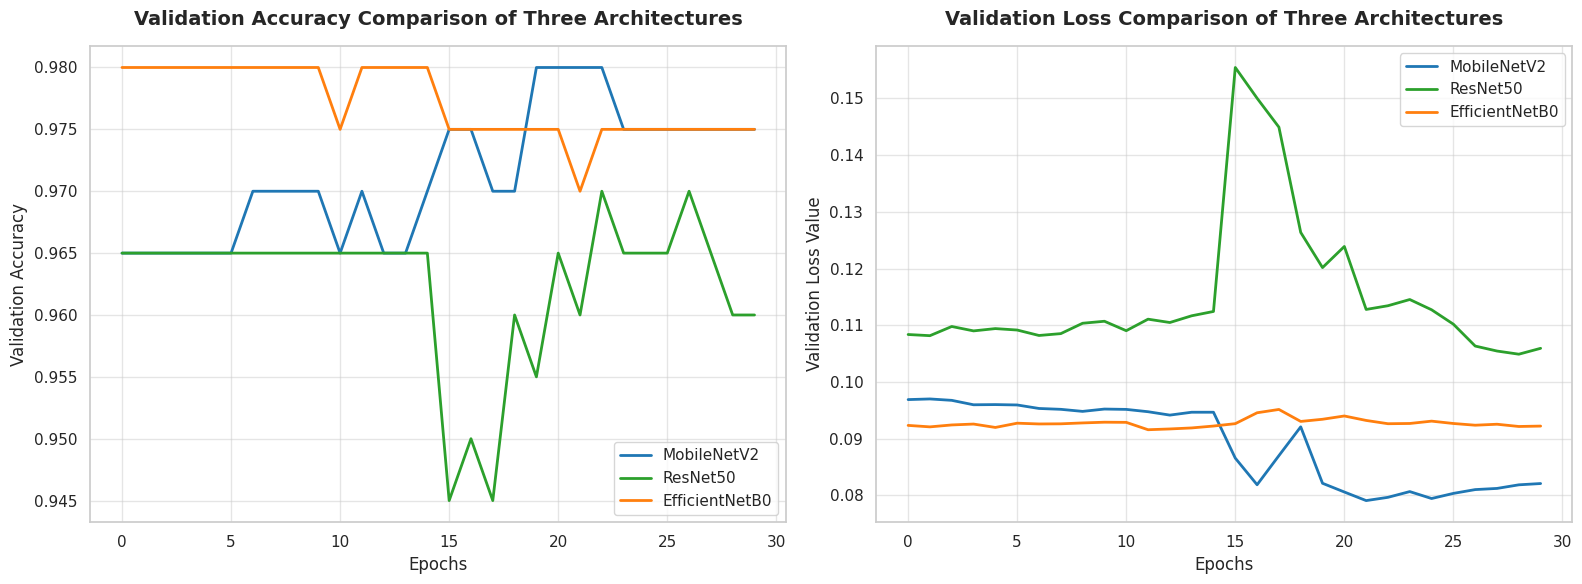

In [37]:
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
epochs_range = range(total_epochs)

plt.figure(figsize=(16, 6))

# Visualization of validation accuracy comparison among the three models
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    histories["mobilenet"].history["val_accuracy"],
    label="MobileNetV2",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    epochs_range,
    histories["resnet"].history["val_accuracy"],
    label="ResNet50",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    epochs_range,
    histories["efficientnet"].history["val_accuracy"],
    label="EfficientNetB0",
    color="#ff7f0e",
    linewidth=2,
)
plt.title(
    "Validation Accuracy Comparison of Three Architectures",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)

# Visualization of validation loss comparison among the three models
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    histories["mobilenet"].history["val_loss"],
    label="MobileNetV2",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    epochs_range,
    histories["resnet"].history["val_loss"],
    label="ResNet50",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    epochs_range,
    histories["efficientnet"].history["val_loss"],
    label="EfficientNetB0",
    color="#ff7f0e",
    linewidth=2,
)
plt.title(
    "Validation Loss Comparison of Three Architectures",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Loss Value", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### **Evaluation Matrix**

In [38]:
# Silence TensorFlow warnings
tf.get_logger().setLevel(logging.ERROR)

# Clear remaining GPU VRAM memory
tf.keras.backend.clear_session()
gc.collect()

# Extract actual labels
y_true = np.concatenate([y.numpy() for _, y in val_dataset], axis=0)

# Model container dictionary
models_dict = {
    "MobileNetV2": model_mobilenet,
    "ResNet50": model_resnet,
    "EfficientNetB0": model_efficientnet,
}

y_preds = {}

# Sequential evaluation
for name, m in models_dict.items():
    print(f"====== CLASSIFICATION REPORT: {name.upper()} ======")

    # Prediction
    y_pred_prob = m.predict(val_dataset, batch_size=16, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_preds[name] = y_pred

    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
    print("")

    # Clear GPU VRAM after each model prediction is complete
    tf.keras.backend.clear_session()
    gc.collect()

====== CLASSIFICATION REPORT: MOBILENETV2 ======
              precision    recall  f1-score   support

       whole       0.98      0.96      0.97        50
      chalky       0.94      0.98      0.96        50
      broken       1.00      0.98      0.99        50
  discolored       0.98      0.98      0.98        50

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.98      0.97      0.98       200


====== CLASSIFICATION REPORT: RESNET50 ======
              precision    recall  f1-score   support

       whole       0.88      0.98      0.92        50
      chalky       0.98      0.88      0.93        50
      broken       1.00      0.98      0.99        50
  discolored       1.00      1.00      1.00        50

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200


====== CLASSIFICATION REPORT: EFF

### **Confusion Matrix**

#### **MobileNetV2**

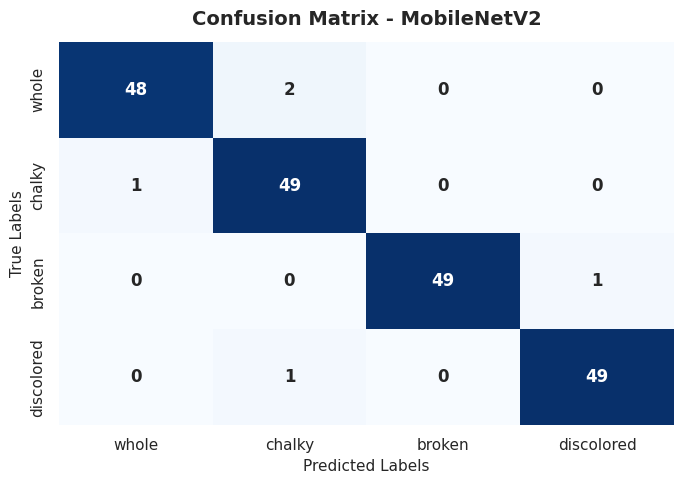

In [39]:
cm_mobilenet = confusion_matrix(y_true, y_preds["MobileNetV2"])
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"},
)
plt.title("Confusion Matrix - MobileNetV2", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Predicted Labels", fontsize=11)
plt.ylabel("True Labels", fontsize=11)
plt.tight_layout()
plt.show()

#### **ResNet50**

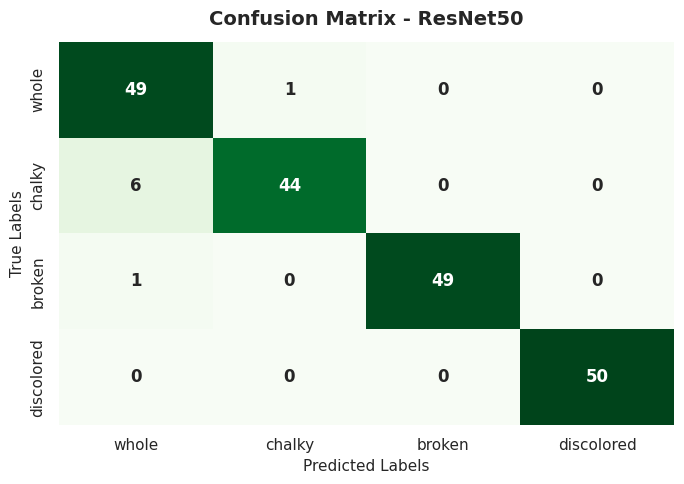

In [40]:
cm_resnet = confusion_matrix(y_true, y_preds["ResNet50"])
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"},
)
plt.title("Confusion Matrix - ResNet50", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Predicted Labels", fontsize=11)
plt.ylabel("True Labels", fontsize=11)
plt.tight_layout()
plt.show()

#### **EfficientNetB0**

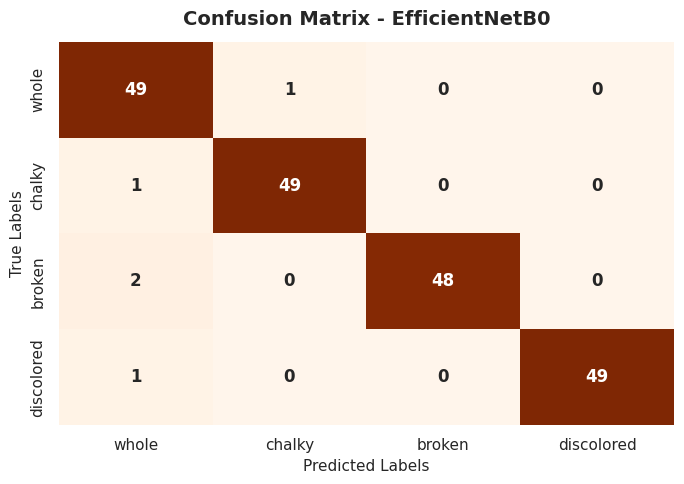

In [41]:
cm_efficientnet = confusion_matrix(y_true, y_preds["EfficientNetB0"])
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_efficientnet,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=False,
    annot_kws={"size": 12, "weight": "bold"},
)
plt.title("Confusion Matrix - EfficientNetB0", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Predicted Labels", fontsize=11)
plt.ylabel("True Labels", fontsize=11)
plt.tight_layout()
plt.show()

### **5-Fold Cross-Validation**

In [42]:
# Initialize 5-Split StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_names = ["mobilenet", "resnet", "efficientnet"]
cv_results = {name: [] for name in model_names}

# Two-Phase Cross-Validation Epochs Configuration
EPOCHS_CV_P1 = 10
EPOCHS_CV_P2 = 10
UNFREEZE_LAYERS = 20

# Callback for smooth convergence during CV
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=0
)

print("====== STARTING 5-FOLD CROSS-VALIDATION PROCESS (TWO-PHASE) ======")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n>>> FOLD {fold}/5 (Train: {len(train_idx)} | Val: {len(val_idx)}) <<<")

    # Split data matrix based on fold indices
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold = X[val_idx], y[val_idx]

    # Convert to dataset
    ds_train = (
        tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold))
        .shuffle(len(X_train_fold))
        .batch(32)
        .prefetch(tf.data.AUTOTUNE)
    )
    ds_val = (
        tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))
        .batch(16)
        .prefetch(tf.data.AUTOTUNE)
    )

    for m_name in model_names:
        # Clear GPU VRAM session before creating a new model
        tf.keras.backend.clear_session()
        gc.collect()

        print(f" Training Model: {m_name.upper()}...")
        temp_model = create_model(m_name)

        # Checkpoint callback to save best weights
        checkpoint_path = f"temp_best_{m_name}_fold{fold}.weights.h5"
        checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        )

        # Phase 1: Feature Extraction
        temp_model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_CV_P1,
            callbacks=[reduce_lr, checkpoint_cb],
            verbose=0,
        )

        # Phase 2: Fine-Tuning
        base_layer = [
            layer
            for layer in temp_model.layers
            if hasattr(layer, "layers") and len(layer.layers) > 10
        ][0]
        base_layer.trainable = True
        for layer in base_layer.layers[:-UNFREEZE_LAYERS]:
            layer.trainable = False

        temp_model.compile(
            optimizer=Adam(learning_rate=1e-5),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        temp_model.fit(
            ds_train,
            validation_data=ds_val,
            epochs=EPOCHS_CV_P2,
            callbacks=[reduce_lr, checkpoint_cb],
            verbose=0,
        )

        # Load the best weights saved during training
        if os.path.exists(checkpoint_path):
            temp_model.load_weights(checkpoint_path)
            os.remove(checkpoint_path)  # Clean up temporary checkpoint file

        # Objective evaluation on validation fold
        _, val_acc = temp_model.evaluate(ds_val, verbose=0)
        cv_results[m_name].append(val_acc)
        print(f" -> Accuracy Score {m_name.upper()} Fold {fold}: {val_acc:.4f}")

        # Delete temporary model object & release VRAM
        del temp_model
        tf.keras.backend.clear_session()
        gc.collect()

# Construct table
df_cv = pd.DataFrame(
    {
        "Fold": [f"Fold {i}" for i in range(1, 6)],
        "MobileNetV2": cv_results["mobilenet"],
        "ResNet50": cv_results["resnet"],
        "EfficientNetB0": cv_results["efficientnet"],
    }
).set_index("Fold")

# Add Mean and Standard Deviation rows
df_summary = df_cv.copy()
df_summary.loc["Mean Accuracy"] = df_cv.mean()
df_summary.loc["Std Dev"] = df_cv.std()

print("\n====== 5-FOLD CROSS-VALIDATION EVALUATION RESULTS TABLE ======")
display(df_summary.round(4))

====== STARTING 5-FOLD CROSS-VALIDATION PROCESS (TWO-PHASE) ======

>>> FOLD 1/5 (Train: 800 | Val: 200) <<<
 Training Model: MOBILENET...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


 -> Accuracy Score MOBILENET Fold 1: 0.9350
 Training Model: RESNET...
 -> Accuracy Score RESNET Fold 1: 0.9050
 Training Model: EFFICIENTNET...
 -> Accuracy Score EFFICIENTNET Fold 1: 0.8950

>>> FOLD 2/5 (Train: 800 | Val: 200) <<<
 Training Model: MOBILENET...
 -> Accuracy Score MOBILENET Fold 2: 0.9150
 Training Model: RESNET...
 -> Accuracy Score RESNET Fold 2: 0.9750
 Training Model: EFFICIENTNET...
 -> Accuracy Score EFFICIENTNET Fold 2: 0.9600

>>> FOLD 3/5 (Train: 800 | Val: 200) <<<
 Training Model: MOBILENET...
 -> Accuracy Score MOBILENET Fold 3: 0.8700
 Training Model: RESNET...
 -> Accuracy Score RESNET Fold 3: 0.9200
 Training Model: EFFICIENTNET...
 -> Accuracy Score EFFICIENTNET Fold 3: 0.9100

>>> FOLD 4/5 (Train: 800 | Val: 200) <<<
 Training Model: MOBILENET...
 -> Accuracy Score MOBILENET Fold 4: 0.8850
 Training Model: RESNET...
 -> Accuracy Score RESNET Fold 4: 0.9250
 Training Model: EFFICIENTNET...
 -> Accuracy Score EFFICIENTNET Fold 4: 0.8900

>>> FOLD 5/5 (T

,MobileNetV2,ResNet50,EfficientNetB0
Fold,,,
Fold 1,0.9350,0.905,0.8950
Fold 2,0.9150,0.975,0.9600
Fold 3,0.8700,0.920,0.9100
Fold 4,0.8850,0.925,0.8900
Fold 5,0.8900,0.910,0.9150
Mean Accuracy,0.8990,0.927,0.9140
Std Dev,0.0258,0.028,0.0277


### **Statistical Significance Test**

In [43]:
# Get 5-fold accuracy values per model
acc_mobilenet = cv_results["mobilenet"]
acc_resnet = cv_results["resnet"]
acc_efficientnet = cv_results["efficientnet"]

print("====== STATISTICAL SIGNIFICANCE TEST ANALYSIS (p-value, alpha = 0.05) ======")

# Paired Hypothesis Test (Paired t-Test)
model_pairs = [
    ("MobileNetV2", "ResNet50", acc_mobilenet, acc_resnet),
    ("MobileNetV2", "EfficientNetB0", acc_mobilenet, acc_efficientnet),
    ("ResNet50", "EfficientNetB0", acc_resnet, acc_efficientnet),
]

p_test_results = []

for m1_name, m2_name, scores1, scores2 in model_pairs:
    t_stat, p_val = stats.ttest_rel(scores1, scores2)
    is_significant = "Yes (Significant)" if p_val < 0.05 else "No (Similar/Identical)"

    p_test_results.append(
        {
            "Pairwise Comparison": f"{m1_name} vs {m2_name}",
            "t-Statistic": round(t_stat, 4),
            "p-Value": round(p_val, 4),
            "Significant (alpha=0.05)": is_significant,
        }
    )

df_p_val = pd.DataFrame(p_test_results)
display(df_p_val)

# Friedman Test (Non-Parametric Repeated Measures)
f_stat, f_pval = stats.friedmanchisquare(acc_mobilenet, acc_resnet, acc_efficientnet)

print("\n====== Friedman Test ======")
print(f"Friedman Statistic : {f_stat:.4f}")
print(f"p-Value Overall    : {f_pval:.4f}")

if f_pval < 0.05:
    print(
        "Conclusion: There is a statistically significant difference in performance among the three architectures."
    )
else:
    print(
        "Conclusion: Overall performance across all three architectures shows no statistically significant difference."
    )

====== STATISTICAL SIGNIFICANCE TEST ANALYSIS (p-value, alpha = 0.05) ======


,Pairwise Comparison,t-Statistic,p-Value,Significant (alpha=0.05)
0,MobileNetV2 vs ResNet50,-1.7569,0.1538,No (Similar/Identical)
1,MobileNetV2 vs EfficientNetB0,-0.9733,0.3855,No (Similar/Identical)
2,ResNet50 vs EfficientNetB0,2.0180,0.1138,No (Similar/Identical)



====== Friedman Test ======
Friedman Statistic : 3.6000
p-Value Overall    : 0.1653
Conclusion: Overall performance across all three architectures shows no statistically significant difference.


### **Model Saving**

In [44]:
model_mobilenet.save("mobilenet.keras")
model_resnet.save("resnet50.keras")
model_efficientnet.save("efficientnet.keras")

### **Computational Efficiency Metrics**

In [46]:
efficiency_data = []

# Take 1 image sample for inference simulation
single_sample = tf.expand_dims(X_val[0], axis=0)

# Dictionary of model filenames
model_files = {
    "MobileNetV2": "mobilenet.keras",
    "ResNet50": "resnet50.keras",
    "EfficientNetB0": "efficientnet.keras",
}

print("====== STARTING COMPUTATIONAL EFFICIENCY METRICS MEASUREMENT ======")

for name, model in models_dict.items():
    # Model parameters
    total_params = model.count_params()
    trainable_params = sum(
        [tf.keras.backend.count_params(w) for w in model.trainable_weights]
    )

    # Model file size
    file_path = model_files.get(name)
    file_size_mb = (
        os.path.getsize(file_path) / (1024 * 1024) if os.path.exists(file_path) else 0
    )

    # GPU Warm-up
    for _ in range(10):
        _ = model(single_sample, training=False)

    # Inference latency measurement
    latencies = []
    for _ in range(100):
        start = time.perf_counter()
        _ = model(single_sample, training=False)
        end = time.perf_counter()
        latencies.append((end - start) * 1000)  # Convert to milliseconds

    avg_latency = float(np.mean(latencies))
    fps = 1000.0 / avg_latency

    efficiency_data.append(
        {
            "Model": name,
            "Total Params": f"{total_params:,}",
            "Trainable Params": f"{trainable_params:,}",
            "File Size (MB)": round(file_size_mb, 2),
            "Latency (ms/img)": round(avg_latency, 2),
            "Throughput (FPS)": round(fps, 1),
        }
    )

df_efficiency = pd.DataFrame(efficiency_data).set_index("Model")
display(df_efficiency)

====== STARTING COMPUTATIONAL EFFICIENCY METRICS MEASUREMENT ======


,Total Params,Trainable Params,File Size (MB),Latency (ms/img),Throughput (FPS)
Model,,,,,
MobileNetV2,"2,587,972","1,535,556",22.18,197.82,5.1
ResNet50,"24,114,308","9,457,412",164.81,261.39,3.8
EfficientNetB0,"4,379,559","1,680,436",30.37,349.68,2.9
